In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_excel('online_course_recommendation_v2 (1).xlsx')

In [13]:
df.head()

,user_id,course_id,course_name,instructor,course_duration_hours,certification_offered,difficulty_level,rating,enrollment_numbers,course_price,feedback_score,study_material_available,time_spent_hours,previous_courses_taken
0,15796,9366,Python for Beginners,Emma Harris,39.1,Yes,Beginner,5.0,21600,317.50,0.797,Yes,17.60,4
1,861,1928,Cybersecurity for Professionals,Alexander Young,36.3,Yes,Beginner,4.3,15379,40.99,0.770,Yes,28.97,9
2,38159,9541,DevOps and Continuous Deployment,Dr. Mia Walker,13.4,Yes,Beginner,3.9,6431,380.81,0.772,Yes,52.44,4
3,44733,3708,Project Management Fundamentals,Benjamin Lewis,58.3,Yes,Beginner,3.1,48245,342.80,0.969,No,22.29,6
4,11285,3361,Ethical Hacking Masterclass,Daniel White,30.8,Yes,Beginner,2.8,34556,381.01,0.555,Yes,22.01,5


In [14]:
df.shape

(100000, 14)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   100000 non-null  int64  
 1   course_id                 100000 non-null  int64  
 2   course_name               100000 non-null  object 
 3   instructor                100000 non-null  object 
 4   course_duration_hours     100000 non-null  float64
 5   certification_offered     100000 non-null  object 
 6   difficulty_level          100000 non-null  object 
 7   rating                    100000 non-null  float64
 8   enrollment_numbers        100000 non-null  int64  
 9   course_price              100000 non-null  float64
 10  feedback_score            100000 non-null  float64
 11  study_material_available  100000 non-null  object 
 12  time_spent_hours          100000 non-null  float64
 13  previous_courses_taken    100000 non-null  in

In [16]:
df.columns

Index(['user_id', 'course_id', 'course_name', 'instructor',
       'course_duration_hours', 'certification_offered', 'difficulty_level',
       'rating', 'enrollment_numbers', 'course_price', 'feedback_score',
       'study_material_available', 'time_spent_hours',
       'previous_courses_taken'],
      dtype='object')

In [17]:
# EDA
df.duplicated().sum()

0

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.isnull().sum()

user_id                     0
course_id                   0
course_name                 0
instructor                  0
course_duration_hours       0
certification_offered       0
difficulty_level            0
rating                      0
enrollment_numbers          0
course_price                0
feedback_score              0
study_material_available    0
time_spent_hours            0
previous_courses_taken      0
dtype: int64

# Univariate Analysis (Single Column)

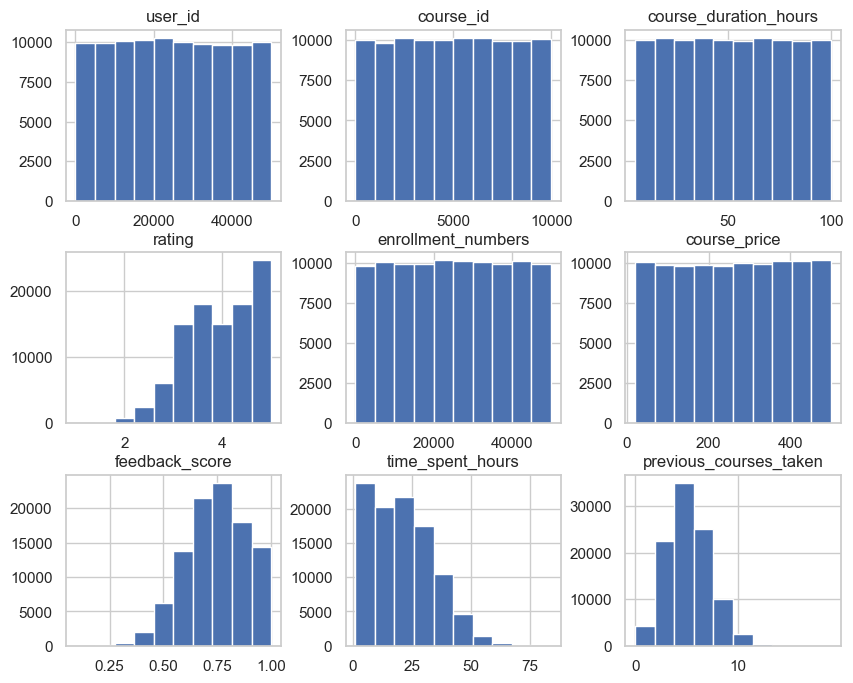

In [23]:
# Numerical Columns
df.hist(figsize=(10,8))
plt.show()

In [24]:
# Categorical Columns
for col in df.select_dtypes(include='object'):
    print(df[col].value_counts())


course_name
Networking and System Administration         5107
Cybersecurity for Professionals              5078
Advanced Machine Learning                    5063
Ethical Hacking Masterclass                  5062
Graphic Design with Canva                    5057
DevOps and Continuous Deployment             5037
Public Speaking Mastery                      5028
Mobile App Development with Swift            5024
Stock Market and Trading Strategies          5022
Data Visualization with Tableau              5010
AI for Business Leaders                      5007
Photography and Video Editing                4995
Project Management Fundamentals              4981
Blockchain and Decentralized Applications    4972
Fundamentals of Digital Marketing            4965
Personal Finance and Wealth Building         4933
Python for Beginners                         4931
Cloud Computing Essentials                   4926
Fitness and Nutrition Coaching               4903
Game Development with Unity           

# Data Visualization

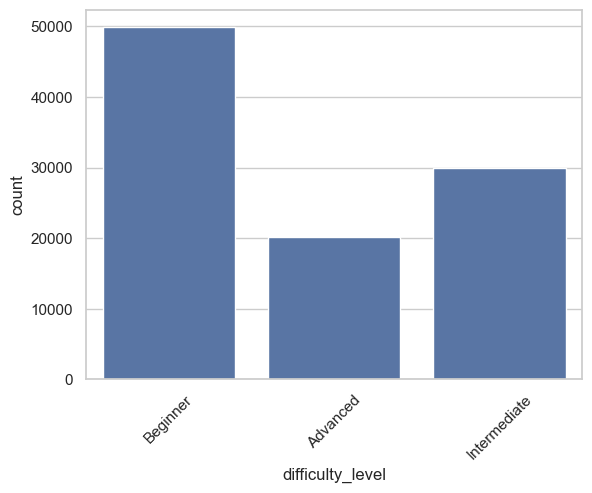

In [25]:
# Count Plot (Category Distribution)
sns.countplot(x='difficulty_level', data=df)
plt.xticks(rotation=45)
plt.show()

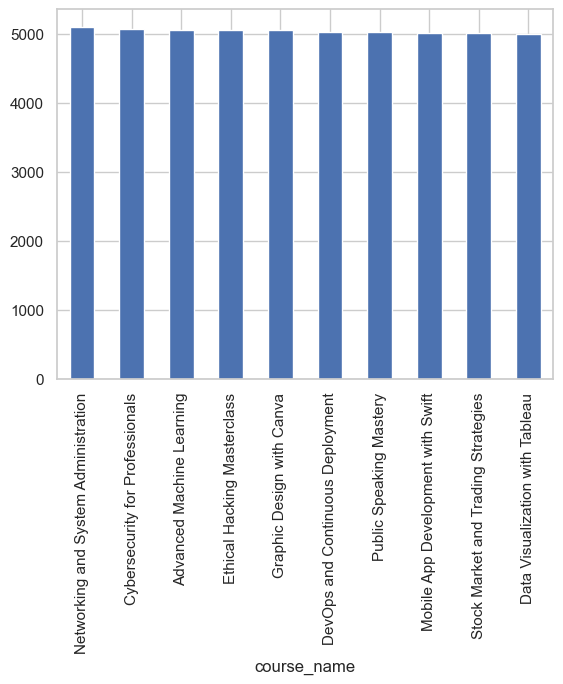

In [26]:
# Top Courses
df['course_name'].value_counts().head(10).plot(kind='bar')
plt.show()

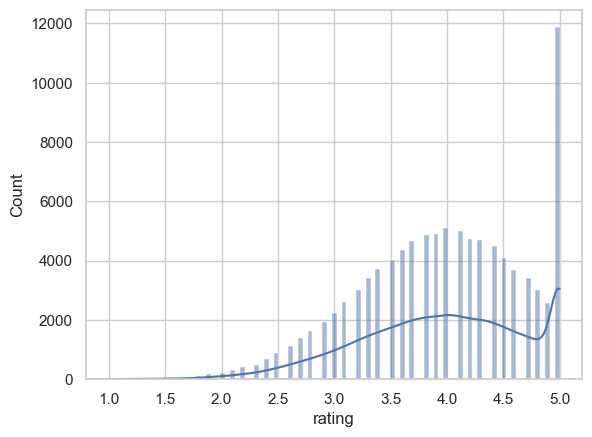

In [27]:
# Ratings Distribution
sns.histplot(df['rating'], kde=True)
plt.show()

# Bivariate Analysis

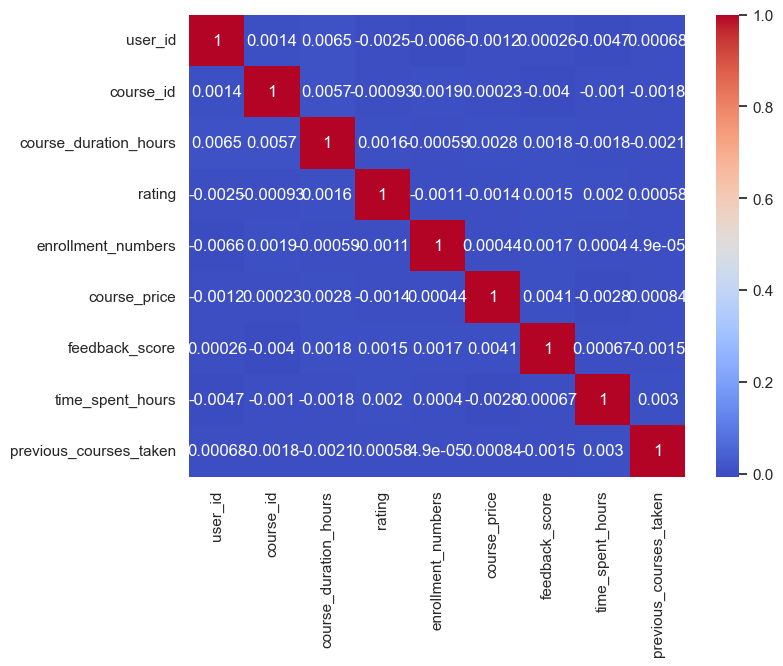

In [28]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

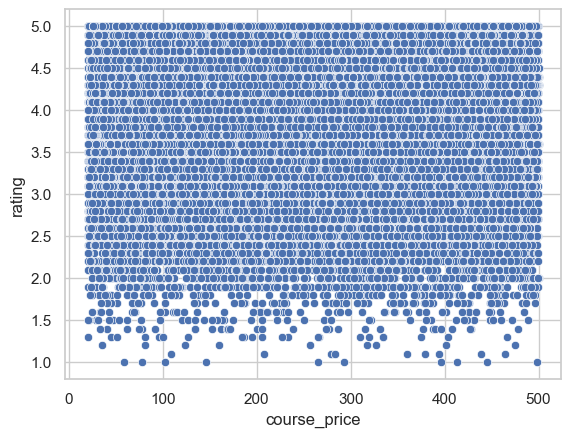

In [29]:
# Price vs Rating
sns.scatterplot(x='course_price', y='rating', data=df)
plt.show()

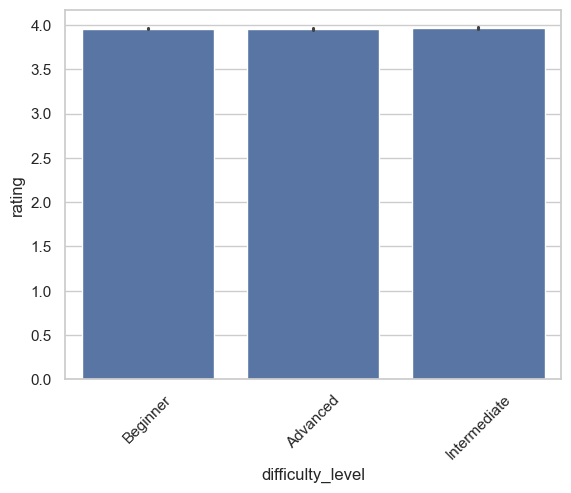

In [30]:
# Category vs Rating
sns.barplot(x='difficulty_level', y='rating', data=df)
plt.xticks(rotation=45)
plt.show()

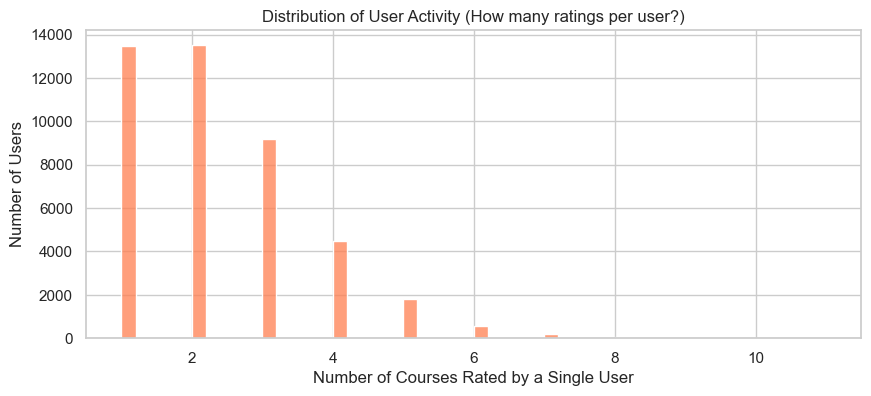

--- Recommendation Pre-Checks ---
Total Unique Users: 43242
Total Unique Courses: 20
Average Ratings per User: 2.31


In [ ]:
# 1. User Activity: How many courses has each user rated?
plt.figure(figsize=(10, 4))
user_interaction_counts = df['user_id'].value_counts()
sns.histplot(user_interaction_counts, bins=50, kde=False, color='coral')
plt.title('Distribution of User Activity (How many ratings per user?)')
plt.xlabel('Number of Courses Rated by a Single User')
plt.ylabel('Number of Users')
plt.show()

# Print useful stats for the next process:
print("--- Recommendation Pre-Checks ---")
print(f"Total Unique Users: {df['user_id'].nunique()}")
print(f"Total Unique Courses: {df['course_name'].nunique()}")
print(f"Average Ratings per User: {user_interaction_counts.mean():.2f}")




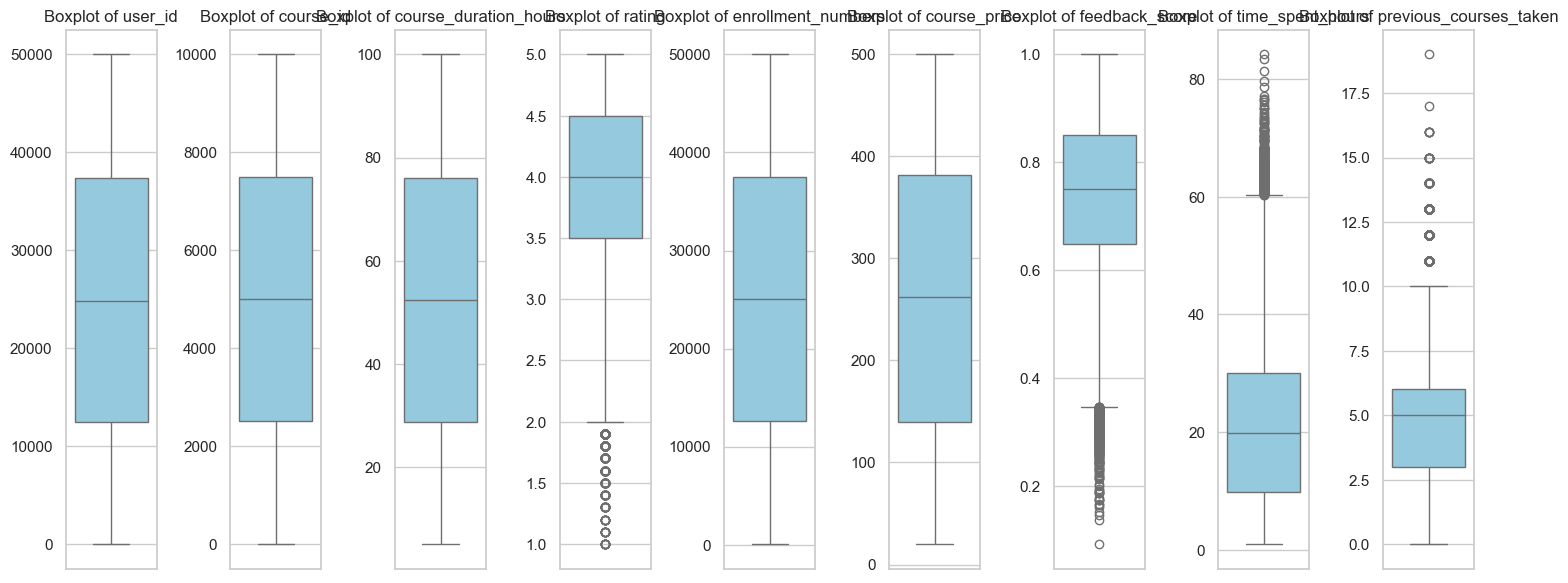

In [32]:
# Select only the numerical columns for boxplots
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Create a boxplot for each numerical column
plt.figure(figsize=(15, 6))

for i, col in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i+1) # Arranges plots side-by-side
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Hides y-label for cleaner look

plt.tight_layout()
plt.show()



In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Create User-Item Matrix (for Collaborative Filtering)
user_item_matrix = df.pivot_table(index='user_id', columns='course_name', values='rating').fillna(0)

# 2. Create TF-IDF Matrix (for Content-Based Filtering)
# We use the course names to find similar words between courses
tfidf = TfidfVectorizer(stop_words='english')
unique_courses = df.drop_duplicates(subset=['course_name']).copy()
tfidf_matrix = tfidf.fit_transform(unique_courses['course_name'].fillna(''))

print("Step 4 Complete: Both data matrices are ready! ")


Step 4 Complete: Both data matrices are ready! 


Model Building


Popularity-Based Recommendation 

In [43]:
# 1. Popularity-Based Recommendation Algorithm
def get_popularity_recommendations(df, top_n=5):
    # Count how many times each course appears in the data
    # We sort by count to find the most popular courses
    popular_courses = df['course_name'].value_counts().head(top_n)
    
    # Return the course names as a list
    return popular_courses.index.tolist()

# Test the algorithm:
print("Top 5 Popular Courses:")
print(get_popularity_recommendations(df))


Top 5 Popular Courses:
['Networking and System Administration', 'Cybersecurity for Professionals', 'Advanced Machine Learning', 'Ethical Hacking Masterclass', 'Graphic Design with Canva']


Content-Based Filtering

In [ ]:
from sklearn.metrics.pairwise import linear_kernel
content_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# 2. Create a lookup table to find courses by name easily
content_sim_df = pd.DataFrame(content_sim, index=unique_courses['course_name'], columns=unique_courses['course_name'])

# 3. Algorithm: Find the top matched courses for a specific course
def get_content_recommendations(course_name, top_n=5):
    if course_name not in content_sim_df.index:
        return "Course not found!"
    
    # Sort courses by similarity and get the top ones (skipping the course itself)
    recommendations = content_sim_df[course_name].sort_values(ascending=False).iloc[1:top_n+1]
    
    return recommendations.index.tolist()




User-Based Collaborative Filtering

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calculate how similar users are to each other
user_sim = cosine_similarity(user_item_matrix)
user_sim_df = pd.DataFrame(user_sim, index=user_item_matrix.index, columns=user_item_matrix.index)

# 2. Algorithm: Find courses based on similar users
def get_user_recommendations(user_id, top_n=5):
    if user_id not in user_sim_df.index:
        return "User ID not found!"
    
    # Find the top 5 users most similar to this user
    similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6].index
    
    # See what courses those similar users liked
    # We take the average rating of courses from those similar users
    sim_user_courses = user_item_matrix.loc[similar_users].mean().sort_values(ascending=False)
    
    # Don't recommend courses the user has already taken
    already_taken = user_item_matrix.columns[user_item_matrix.loc[user_id] > 0]
    recommendations = sim_user_courses.drop(already_taken, errors='ignore').head(top_n)
    
    return recommendations.index.tolist()




Item-Based Collaborative Filtering

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calculate similarity between Courses (using the transposed matrix)
item_sim = cosine_similarity(user_item_matrix.T)
item_sim_df = pd.DataFrame(item_sim, index=user_item_matrix.columns, columns=user_item_matrix.columns)

# 2. Algorithm: Find courses similar to what the user liked before
def get_item_recommendations(user_id, top_n=5):
    if user_id not in user_item_matrix.index:
        return "User ID not found!"
    
    # Mathematical shortcut: Multiply user ratings against course similarities
    # This automatically finds courses similar to everything the user rated highly
    user_ratings = user_item_matrix.loc[user_id]
    scores = item_sim_df.dot(user_ratings).sort_values(ascending=False)
    
    # Don't recommend courses the user has already taken
    already_taken = user_item_matrix.columns[user_item_matrix.loc[user_id] > 0]
    recommendations = scores.drop(already_taken, errors='ignore').head(top_n)
    
    return recommendations.index.tolist()



 Hybrid Recommendation System

In [ ]:
# 5. Hybrid Recommendation Algorithm
def get_hybrid_recommendations(user_id, course_name, top_n=5):
    # 1. Get Content-Based Scores (similarity of the course text)
    if course_name in content_sim_df.index:
        content_scores = content_sim_df[course_name]
    else:
        content_scores = pd.Series(0, index=user_item_matrix.columns)
        
    # 2. Get User-Based Scores (what similar users liked)
    if user_id in user_sim_df.index:
        # We find similar users and get their average ratings for all courses
        similar_users = user_sim_df[user_id].sort_values(ascending=False).iloc[1:6].index
        user_scores = user_item_matrix.loc[similar_users].mean()
    else:
        user_scores = pd.Series(0, index=user_item_matrix.columns)
    
    # 3. Combine the scores (50% Content + 50% User-Based)
    hybrid_scores = (content_scores * 0.5) + (user_scores * 0.5)
    
    # 4. Remove courses the user has already taken
    already_taken = user_item_matrix.columns[user_item_matrix.loc[user_id] > 0]
    recommendations = hybrid_scores.drop(already_taken, errors='ignore').sort_values(ascending=False).head(top_n)
    
    return recommendations.index.tolist()



Evaluation

In [ ]:
# RMSE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.decomposition import TruncatedSVD

# 1. Split your data: 80% for training, 20% for testing (test_size=0.2)
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# 2. Re-run Matrix Factorization logic on the training set
train_matrix = train_data


In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from math import sqrt

# Only keep users who rated at least 5 courses (active users)
active_users = train_data.groupby('user_id').size()
active_users = active_users[active_users >= 5].index.tolist()

# Sample 2000 active users max (saves memory!)
if len(active_users) > 2000:
    active_users = pd.Series(active_users).sample(2000, random_state=42).tolist()

# Build small train matrix with only active users
small_train = train_data[train_data['user_id'].isin(active_users)]
small_matrix = small_train.pivot_table(index='user_id', columns='course_name', values='rating').fillna(0)

# Similarity matrices (now small enough to fit in memory)
user_sim = cosine_similarity(small_matrix)
item_sim = cosine_similarity(small_matrix.T)

# Predictions
user_pred = np.dot(user_sim, small_matrix.values) / np.abs(user_sim).sum(axis=1, keepdims=True)
item_pred = np.dot(small_matrix.values, item_sim)

user_pred_df = pd.DataFrame(user_pred, index=small_matrix.index, columns=small_matrix.columns)
item_pred_df = pd.DataFrame(item_pred, index=small_matrix.index, columns=small_matrix.columns)

# Filter test data to only active users
test_f = test_data[
    test_data['user_id'].isin(small_matrix.index) & 
    test_data['course_name'].isin(small_matrix.columns)
]

y_true = test_f['rating'].values
avg = df['rating'].mean()

y_pop = [avg] * len(y_true)
y_user = [user_pred_df.loc[r['user_id'], r['course_name']] for _, r in test_f.iterrows()]
y_item = [item_pred_df.loc[r['user_id'], r['course_name']] for _, r in test_f.iterrows()]
y_hybrid = [(u + i) / 2 for u, i in zip(y_user, y_item)]

# Results
def rmse(yt, yp):
    return round(sqrt(mean_squared_error(yt, yp)), 4)

print(f"Evaluated on {len(y_true)} test ratings from {len(active_users)} active users")
print(" Model Comparison (Lower RMSE = Better)")
print(f"Popularity : {rmse(y_true, y_pop)}")
print(f"User-Based : {rmse(y_true, y_user)}")
print(f"Item-Based : {rmse(y_true, y_item)}")
print(f"Hybrid     : {rmse(y_true, y_hybrid)}")


Evaluated on 472 test ratings from 1167 active users
📊 Model Comparison (Lower RMSE = Better)
Popularity : 0.7287
User-Based : 3.1148
Item-Based : 1.9559
Hybrid     : 1.7089
